<a href="https://colab.research.google.com/github/Avichatt/-Personal-Finance-Calculator/blob/main/Week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/a10.csv")
df.columns = ['date', 'sales']
df['date'] = pd.to_datetime(df['date'])

df.set_index('date', inplace=True)   # modifies df directly, no assignment
df.iloc[5:10] = None
df = df.fillna(method='ffill')
df.head()

/tmp/ipykernel_820/1674090936.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


,sales
date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869


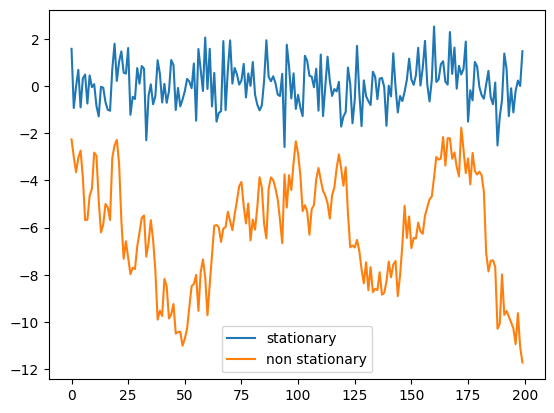

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#stationary
x = np.random.normal(0, 1, 200)

#non stationary
y = np.cumsum(np.random.normal(0, 1, 200))


plt.plot(x, label='stationary')
plt.plot(y ,label= 'non stationary')
plt.legend()




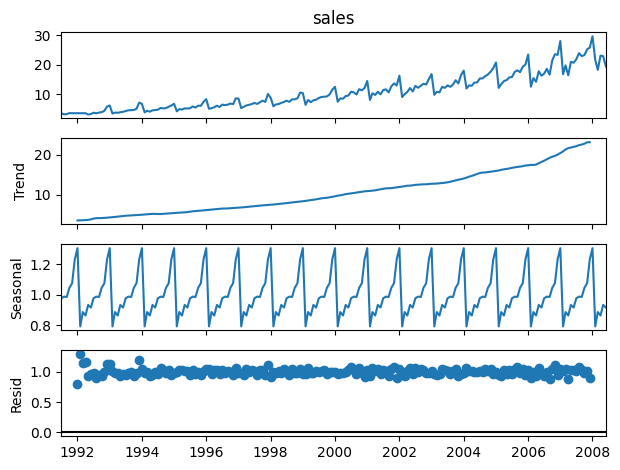

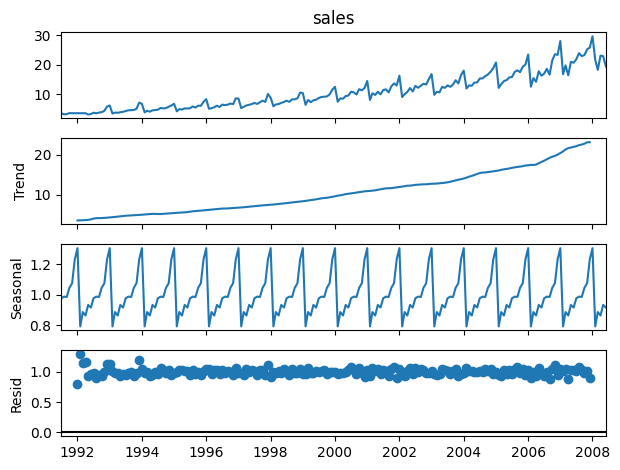

In [ ]:
#plot raw series
#Apply log transform
#Apply differencing

df['log'] = np.log(df['sales'])
df['diff'] = df['log'].diff()


from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df['sales'], model='multiplicative')

decomp.plot()


<Axes: title={'center': 'sales'}, xlabel='month'>

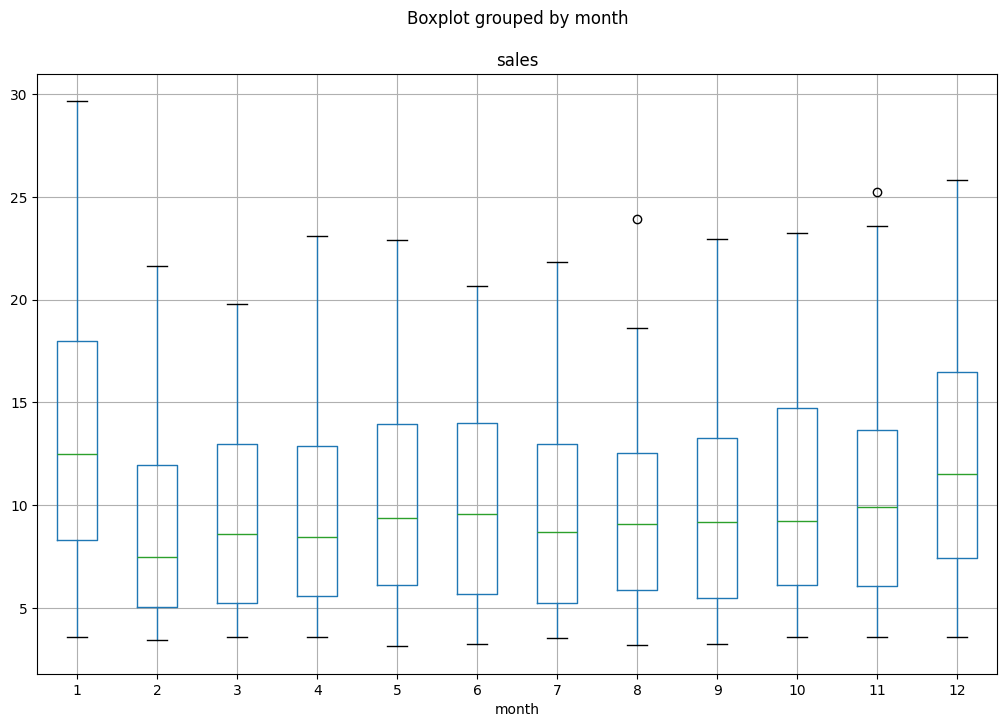

In [ ]:
df['month'] = df.index.month
df.boxplot(column='sales', by='month', figsize=(12,8))


In [ ]:

import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# 1. Load dataset
df = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/a10.csv")

# 2. Rename columns
df.columns = ['date', 'sales']

# 3. Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# 4. Set date as index (no inplace=True to avoid NoneType issue)
df = df.set_index('date')

# 5. Create calendar features
df['month'] = df.index.month
df['quarter'] = df.index.quarter
df['year'] = df.index.year

# 6. Cyclical encoding for month
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

# 7. Lag features
df['lag_1'] = df['sales'].shift(1)    # previous month
df['lag_12'] = df['sales'].shift(12)  # same month last year

# 8. Seasonal differencing
df['seasonal_diff'] = df['sales'] - df['sales'].shift(12)

# 9. Quick look at the engineered features
print(df.head(15))

decomp = seasonal_decompose(df['sales'], period=12)
df['trend'] = decomp.trend
df['seasonal'] = decomp.seasonal
df['residual'] = decomp.resid

df_model = df.dropna()

features = ['month', 'quarter', 'year', 'sin_month', 'cos_month', 'lag_1', 'lag_12', 'seasonal_diff', 'trend', 'seasonal', 'residual']


x = df_model[features]
y = df_model['sales']


#sanity checks

print("features data shape", x.shape)
print("target data shape", y.shape)
print("\n Sample features: \n", x.head())





               sales  month  quarter  year     sin_month     cos_month  \
date                                                                     
1991-07-01  3.526591      7        3  1991 -5.000000e-01 -8.660254e-01   
1991-08-01  3.180891      8        3  1991 -8.660254e-01 -5.000000e-01   
1991-09-01  3.252221      9        3  1991 -1.000000e+00 -1.836970e-16   
1991-10-01  3.611003     10        4  1991 -8.660254e-01  5.000000e-01   
1991-11-01  3.565869     11        4  1991 -5.000000e-01  8.660254e-01   
1991-12-01  4.306371     12        4  1991 -2.449294e-16  1.000000e+00   
1992-01-01  5.088335      1        1  1992  5.000000e-01  8.660254e-01   
1992-02-01  2.814520      2        1  1992  8.660254e-01  5.000000e-01   
1992-03-01  2.985811      3        1  1992  1.000000e+00  6.123234e-17   
1992-04-01  3.204780      4        2  1992  8.660254e-01 -5.000000e-01   
1992-05-01  3.127578      5        2  1992  5.000000e-01 -8.660254e-01   
1992-06-01  3.270523      6        2  

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/tmp/ipykernel_820/1617809029.py:24: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(pd.date_range(df.index[-1], periods=3, freq='M'), forecast,


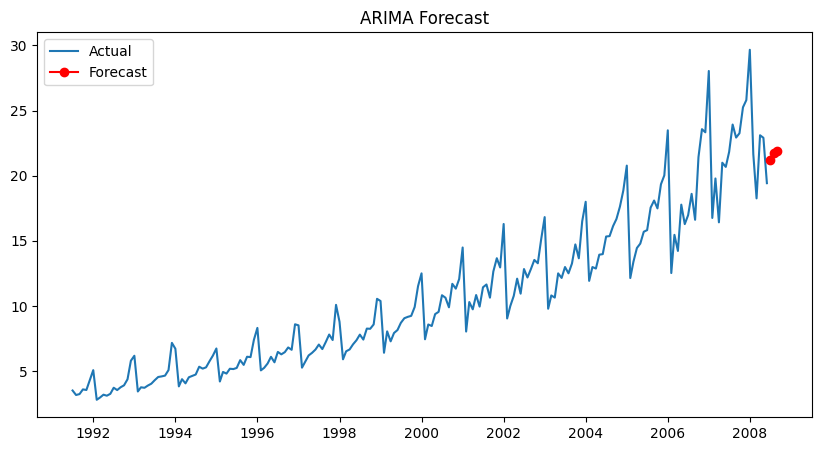

Forecasted sales for next 3 months:
2008-07-01    21.203379
2008-08-01    21.736449
2008-09-01    21.896846
Freq: MS, Name: predicted_mean, dtype: float64


In [ ]:
#ARIMA model

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# 1. Load dataset
df = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/a10.csv")
df.columns = ['date', 'sales']
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

# 2. Fit ARIMA model
# (p,d,q) = (1,1,1) is just an example; you can tune these
model = ARIMA(df['sales'], order=(1,1,1))
model_fit = model.fit()

# 3. Forecast next 3 months
forecast = model_fit.forecast(steps=3)

# 4. Plot actual series + forecast
plt.figure(figsize=(10,5))
plt.plot(df['sales'], label='Actual')
plt.plot(pd.date_range(df.index[-1], periods=3, freq='M'), forecast,
         label='Forecast', color='red', marker='o')
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

# 5. Print forecasted values
print("Forecasted sales for next 3 months:")
print(forecast)


In [ ]:
n_size = int(len(df)*0.0)
train =df['sales'][:]
test = df['sales'][-n_size:]


from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
import numpy as np

mse = mean_squared_error(test, forecast)
rmse = sqrt(mse)
mae = mean_absolute_error

print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


MSE: 162.16
RMSE: 12.73


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


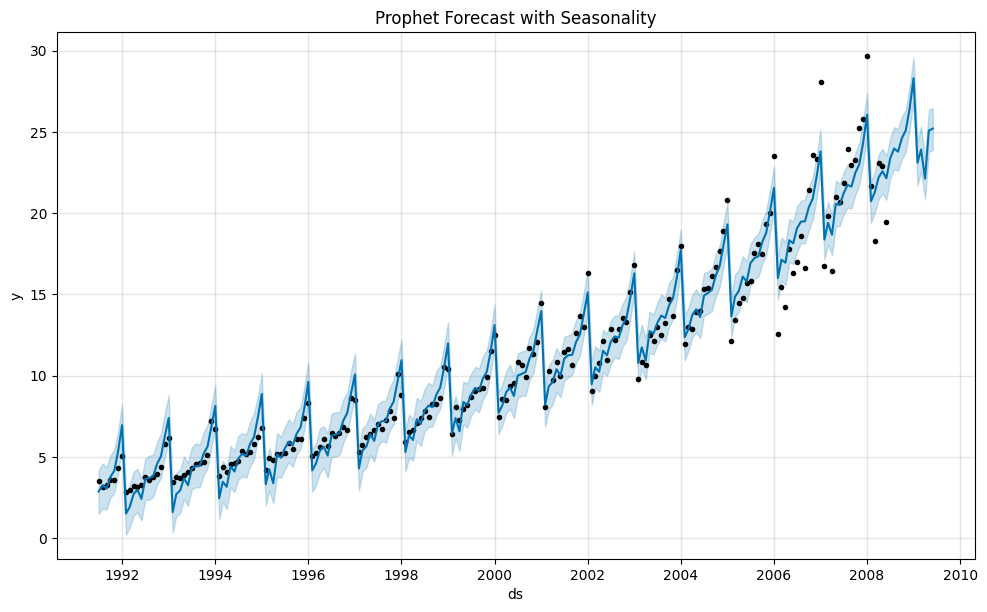

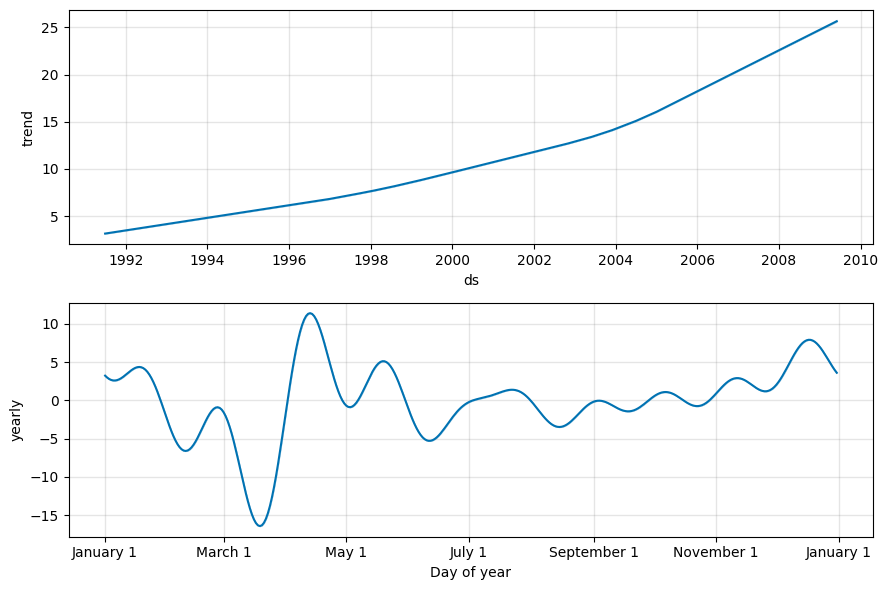

In [ ]:
#Prophet Model


import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# 1. Load dataset
df = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/a10.csv")
df.columns = ['ds', 'y']   # Prophet requires columns named 'ds' (date) and 'y' (value)

# 2. Initialize and fit Prophet model
model = Prophet(yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=False)
model.fit(df)

# 3. Make a future dataframe (extend timeline)
future = model.make_future_dataframe(periods=12, freq='M')  # 12 months ahead
forecast = model.predict(future)

# 4. Plot forecast
model.plot(forecast)
plt.title("Prophet Forecast with Seasonality")
plt.show()

# 5. Plot seasonality components (trend, yearly seasonality, etc.)
model.plot_components(forecast)
plt.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


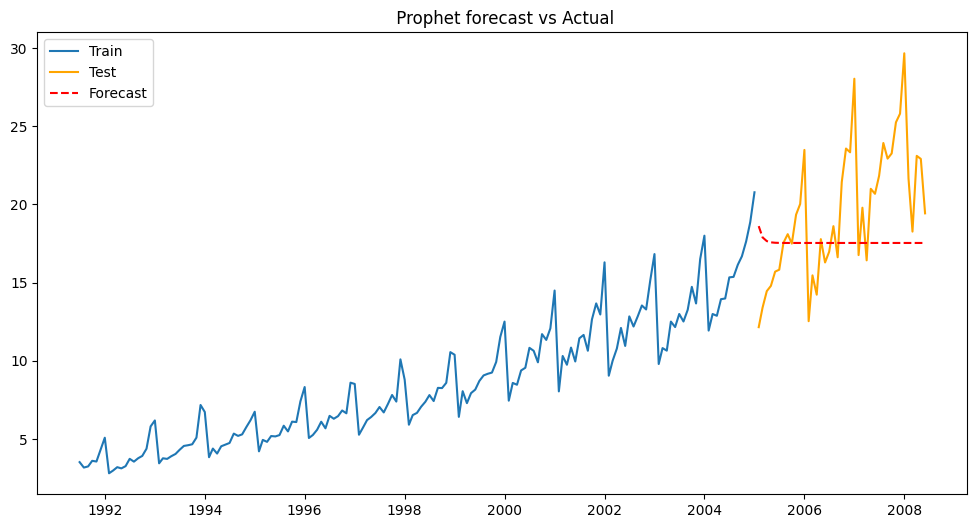

Forecasted values:
2005-02-01    18.615225
2005-03-01    17.896404
2005-04-01    17.657575
2005-05-01    17.578225
2005-06-01    17.551861
2005-07-01    17.543101
2005-08-01    17.540191
2005-09-01    17.539224
2005-10-01    17.538903
2005-11-01    17.538796
2005-12-01    17.538760
2006-01-01    17.538749
2006-02-01    17.538745
2006-03-01    17.538743
2006-04-01    17.538743
2006-05-01    17.538743
2006-06-01    17.538743
2006-07-01    17.538743
2006-08-01    17.538743
2006-09-01    17.538743
2006-10-01    17.538743
2006-11-01    17.538743
2006-12-01    17.538743
2007-01-01    17.538743
2007-02-01    17.538743
2007-03-01    17.538743
2007-04-01    17.538743
2007-05-01    17.538743
2007-06-01    17.538743
2007-07-01    17.538743
2007-08-01    17.538743
2007-09-01    17.538743
2007-10-01    17.538743
2007-11-01    17.538743
2007-12-01    17.538743
2008-01-01    17.538743
2008-02-01    17.538743
2008-03-01    17.538743
2008-04-01    17.538743
2008-05-01    17.538743
2008-06-01    17.5387

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# 1. Load dataset
df = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/a10.csv")
df.columns = ['date', 'sales']
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

# 2. Train/Test split
train_size = int(len(df) * 0.8)   # 80% train, 20% test
train, test = df.iloc[:train_size], df.iloc[train_size:]

# 3. Fit ARIMA model on train set
model = ARIMA(train['sales'], order=(1,1,1))   # (p,d,q) chosen as example
model_fit = model.fit()

# 4. Forecast for length of test set
forecast = model_fit.forecast(steps=len(test))

# 5. Plot train, test, and forecast
plt.figure(figsize=(12,6))
plt.plot(train.index, train['sales'], label='Train')
plt.plot(test.index, test['sales'], label='Test', color='orange')
plt.plot(test.index, forecast, label='Forecast', color='red', linestyle='--')
plt.title(" Prophet forecast vs Actual")
plt.legend()
plt.show()

# 6. Print forecasted values
print("Forecasted values:")
print(forecast)


In [ ]:
# TAXIS DATASET




import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Load Dataset
print("Loading dataset...")

df_raw = sns.load_dataset('taxis')
print("Raw DF")


# Convert 'pickup' and 'dropoff' to datetime
df_raw['pickup'] = pd.to_datetime(df_raw['pickup'])
df_raw['dropoff'] = pd.to_datetime(df_raw['dropoff'])
print(df_raw.head())


# 2. EDA and Visualization
print("\nStarting EDA...")
df_eda = df_raw.copy()


# Add day of week and date
df_eda['pickup_date'] = df_eda['pickup'].dt.date
df_eda['day_of_week'] = df_eda['pickup'].dt.day_name()
df_eda['pickup_hour'] = df_eda['pickup'].dt.hour

# Define order of days
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']



Loading dataset...
Raw DF
               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  U

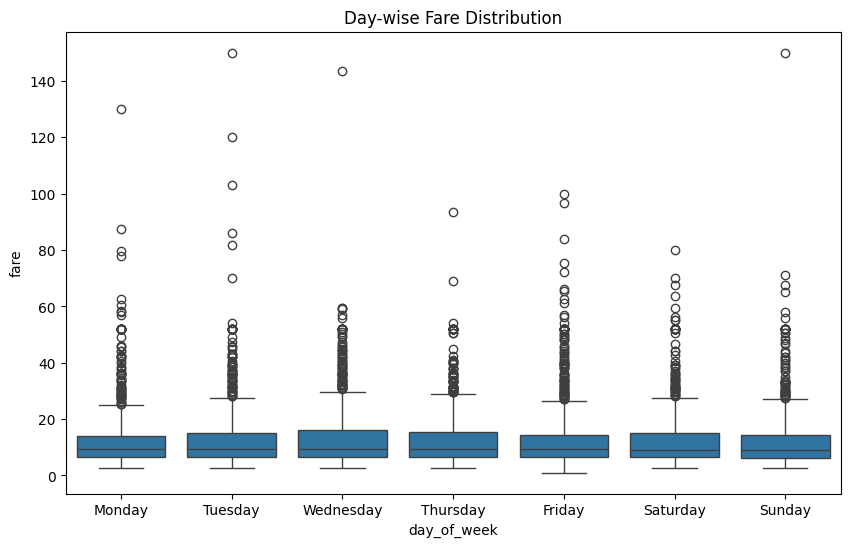

- Saved daywise_fare_boxplot.png


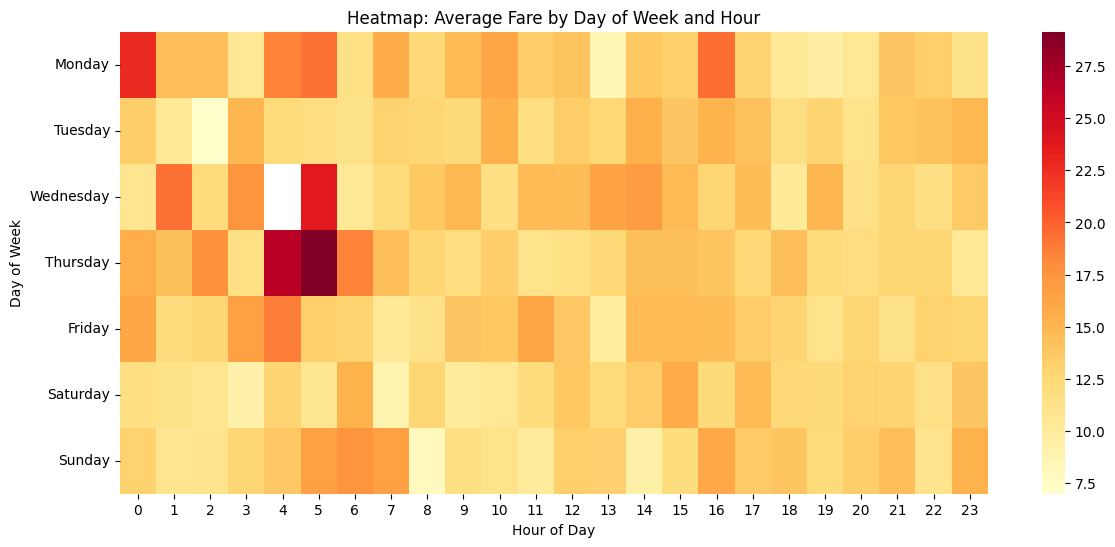

- Saved daywise_fare_heatmap.png


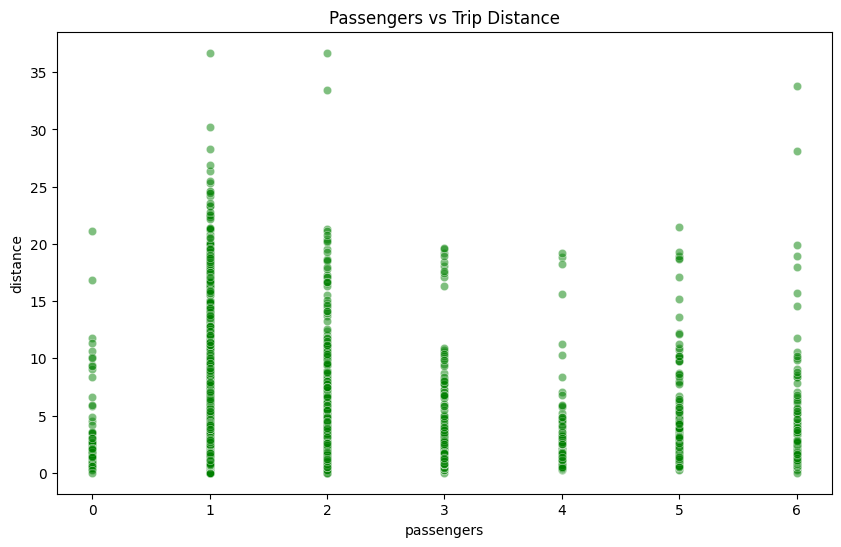

- Saved passengers_vs_distance.png


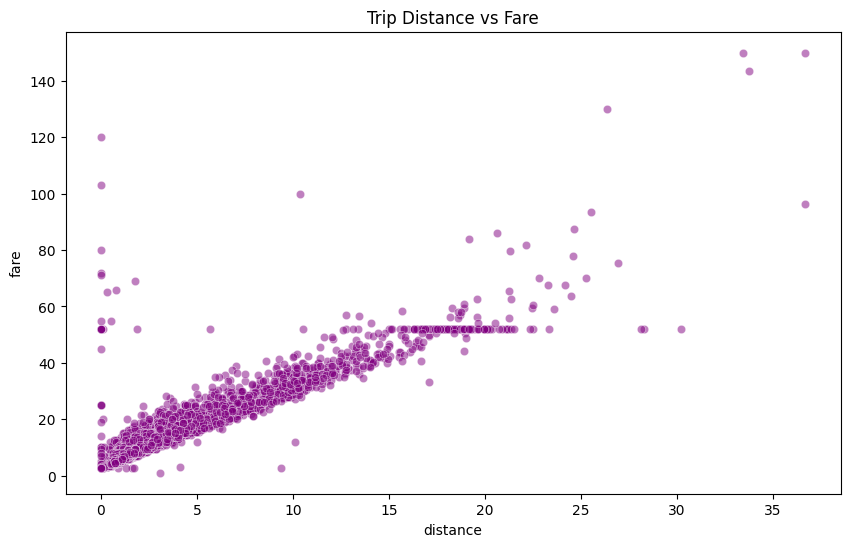

- Saved distance_vs_fare.png


In [ ]:
# --- Chart 1: Day-wise fare ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='day_of_week', y='fare', data=df_eda, order=days_order)
plt.title('Day-wise Fare Distribution')
plt.savefig(f'daywise_fare_boxplot.png')
plt.show()

print("- Saved daywise_fare_boxplot.png")

# --- Heatmap: Daywise average fare by hour ---
heatmap_data = pd.pivot_table(df_eda, values='fare', index='day_of_week', columns='pickup_hour', aggfunc='mean')
heatmap_data = heatmap_data.reindex(days_order)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False)
plt.title('Heatmap: Average Fare by Day of Week and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.savefig(f'daywise_fare_heatmap.png')
plt.show()

print("- Saved daywise_fare_heatmap.png")

# --- Chart 2: Passengers vs Trip Distance ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x='passengers', y='distance', data=df_eda, alpha=0.5, color='green')
plt.title('Passengers vs Trip Distance')
plt.savefig(f'passengers_vs_distance.png')
plt.show()

print("- Saved passengers_vs_distance.png")

# --- Chart 3: Trip Distance vs Fare ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x='distance', y='fare', data=df_eda, alpha=0.5, color='purple')
plt.title('Trip Distance vs Fare')
plt.savefig(f'distance_vs_fare.png')
plt.show()

print("- Saved distance_vs_fare.png")



In [ ]:
import numpoy as np
import random

def sigmoid(x):
  return 1/()

ModuleNotFoundError: No module named 'numpoy'

In [ ]:
from sklearn.preprocessing import standardScaler
scaler = StandardScaler()


def process_stream(chunk)
cleaned_chunk = hospital_cleaning_pipeline(chunk)


numerical_col =['Age',  'Billing Amount']
cleaned_chunk[numerical_cols] = scaler.fit.transform(cleaned_chunk[numerical_cols])
return cleaned_chunk


df_stream = pd.read_csv('hospital_data.csv', chunksize = 1000)

for i, chunk in enumerate(df_stream):
  if i == 0:
    print("columns in first chunk", chunk.column)
    processed_chunk = process_stream(chunk)
    print("columns in processed chunk 5 rows)
    print(processed_chunk.head())





In [ ]:
pip  install torch torchvision matplotlib pillow

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform

# load the built in high quality image
img_raw = data.astronaut()
img_raw = transform.resize(img_raw, (256, 224))

plt.figure(figsize=(10, 10))
plt.imshow(img_raw, cmap='gray')   # <-- fixed here
plt.title("ready for feature extraction")
plt.axis('off')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform
from scipy.signal import convolve2d

# Load and resize image
img_raw = data.astronaut()
img_raw = transform.resize(img_raw, (256, 224))

# Convert to grayscale
img_gray = color.rgb2gray(img_raw)

# Define Sobel-like kernel (edge detection)
kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
])

# Apply convolution
img_conv = convolve2d(img_gray, kernel, mode='valid')

# Plot result
plt.figure(figsize=(10, 10))
plt.imshow(img_conv, cmap='magma')
plt.colorbar()
plt.title("Edge Detection with Convolution")
plt.axis('off')
plt.show()



In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from skimage import data, transform
import numpy as np
import matplotlib.pyplot as plt

# Load VGG16 model without top classification layers
model = VGG16(weights='imagenet', include_top=False)

# Load and resize image
raw_img = data.astronaut()
img = transform.resize(raw_img, (224, 224))  # resize to VGG16 input size

# Prepare image for VGG16
x = np.expand_dims(img, axis=0)        # add batch dimension
x = preprocess_input(x.astype(np.float32))  # preprocess for VGG16

# Extract features from block3_conv1
mid_layer_model = tf.keras.Model(inputs=model.input,
                                 outputs=model.get_layer('block3_conv1').output)
mid_features = mid_layer_model.predict(x)

# Visualize two channels from block3_conv1
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

im0 = ax[0].imshow(mid_features[0, :, :, 0], cmap='magma')
ax[0].set_title('Block 3 Conv1 - Channel 0')
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(mid_features[0, :, :, 1], cmap='magma')
ax[1].set_title('Block 3 Conv1 - Channel 1')
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

plt.show()


In [ ]:
from skimage import io
import matplotlib.pyplot as plt

# Load the image from URL
img_url = "https://images.unsplash.com/photo-1464822759023-fed622ff2c3b?q=80&w=1000&auto=format&fit=crop"
raw_img = io.imread(img_url)

# Show the actual image
plt.imshow(raw_img)
plt.axis("off")   # hide axes
plt.title("Original Mountain Image")
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from skimage import io, transform
import numpy as np
import matplotlib.pyplot as plt

# Load VGG16 model without top classification layers
model = VGG16(weights='imagenet', include_top=False)

# Load and resize image (Mountain)
# Using a public image URL
img_url = "https://images.unsplash.com/photo-1464822759023-fed622ff2c3b?q=80&w=1000&auto=format&fit=crop"
raw_img = io.imread(img_url)
img = transform.resize(raw_img, (224, 224))  # resize to VGG16 input size

#Prepare image for VGG16
x = np.expand_dims(img, axis=0)        # add batch dimension
if x.shape[-1] == 4:
  x = x[:, :, :, :3]
x = preprocess_input(x.astype(np.float32))  # preprocess for VGG16

#Extract features from block3_conv1
mid_layer_model = tf.keras.Model(inputs=model.input,
outputs=model.get_layer('block3_conv1').output)
mid_features = mid_layer_model.predict(x)

#Visualize two channels from block3_conv1
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

im0 = ax[0].imshow(mid_features[0, :, :, 0], cmap='viridis')
ax[0].set_title('Block 3 Conv1 - Channel 0 (Mountain)')
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(mid_features[0, :, :, 1], cmap='viridis')
ax[1].set_title('Block 3 Conv1 - Channel 1')
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [ ]:
from skimage import io
import matplotlib.pyplot as plt

# Load the image from URL
img_url = "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?q=80&w=1000&auto=format&fit=crop"
raw_img = io.imread(img_url)

# Show the actual image
plt.imshow(raw_img)
plt.axis("off")   # hide axes
plt.title("Cat")
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from skimage import io, transform
import numpy as np
import matplotlib.pyplot as plt

# Load VGG16 model without top classification layers
model = VGG16(weights='imagenet', include_top=False)

# Load and resize image (Cat)
# Using a public image URL
img_url = "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?q=80&w=1000&auto=format&fit=crop"
raw_img = io.imread(img_url)
img = transform.resize(raw_img, (224, 224))  # resize to VGG16 input size

# Prepare image for VGG16
x = np.expand_dims(img, axis=0)        # add batch dimension
if x.shape[-1] == 4: # handle RGBA
    x = x[:, :, :, :3]
x = preprocess_input(x.astype(np.float32))  # preprocess for VGG16

# Extract features from block3_conv1
mid_layer_model = tf.keras.Model(inputs=model.input,
                                 outputs=model.get_layer('block3_conv1').output)
mid_features = mid_layer_model.predict(x)

# Visualize two channels from block3_conv1
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

im0 = ax[0].imshow(mid_features[0, :, :, 0], cmap='magma')
ax[0].set_title('Block 3 Conv1 - Channel 0 (Cat)')
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(mid_features[0, :, :, 1], cmap='magma')
ax[1].set_title('Block 3 Conv1 - Channel 1')
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [ ]:
from skimage import io
import matplotlib.pyplot as plt

# Load the image from URL
img_url = "https://images.unsplash.com/photo-1449824913935-59a10b8d2000?q=80&w=1000&auto=format&fit=crop"
raw_img = io.imread(img_url)

# Show the actual image
plt.imshow(raw_img)
plt.axis("off")   # hide axes
plt.title("City")
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from skimage import io, transform
import numpy as np
import matplotlib.pyplot as plt

# Load VGG16 model without top classification layers
model = VGG16(weights='imagenet', include_top=False)

# Load and resize image (City Skyline)
# Using a public image URL
img_url = "https://images.unsplash.com/photo-1449824913935-59a10b8d2000?q=80&w=1000&auto=format&fit=crop"
raw_img = io.imread(img_url)
img = transform.resize(raw_img, (224, 224))  # resize to VGG16 input size

# Prepare image for VGG16
x = np.expand_dims(img, axis=0)        # add batch dimension
if x.shape[-1] == 4: # handle RGBA
    x = x[:, :, :, :3]
x = preprocess_input(x.astype(np.float32))  # preprocess for VGG16

# Extract features from block3_conv1
mid_layer_model = tf.keras.Model(inputs=model.input,
                                 outputs=model.get_layer('block3_conv1').output)
mid_features = mid_layer_model.predict(x)

# Visualize two channels from block3_conv1
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

im0 = ax[0].imshow(mid_features[0, :, :, 0], cmap='magma')
ax[0].set_title('Block 3 Conv1 - Channel 0 (City)')
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(mid_features[0, :, :, 1], cmap='magma')
ax[1].set_title('Block 3 Conv1 - Channel 1')
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, transform
from scipy.signal import convolve2d

# Load and resize image
img_url = "https://images.unsplash.com/photo-1449824913935-59a10b8d2000?q=80&w=1000&auto=format&fit=crop"
raw_img = io.imread(img_url)
img = transform.resize(raw_img, (224, 224))   # resize to manageable size

# Convert to grayscale
img_gray = color.rgb2gray(img)

# Define Sobel-like kernel (edge detection)
kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
])

# Apply convolution
img_conv = convolve2d(img_gray, kernel, mode='same')  # use 'same' to preserve dimensions

# Plot result
plt.figure(figsize=(10, 10))
plt.imshow(img_conv, cmap='magma')
plt.colorbar()
plt.title("Edge Detection with Convolution")
plt.axis('off')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, transform
from scipy.signal import convolve2d

# Load and resize image
img_url = "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?q=80&w=1000&auto=format&fit=crop"
raw_img = io.imread(img_url)
img = transform.resize(raw_img, (224, 224))   # resize to manageable size

# Convert to grayscale
img_gray = color.rgb2gray(img)

# Define Sobel-like kernel (edge detection)
kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
])

# Apply convolution
img_conv = convolve2d(img_gray, kernel, mode='same')  # use 'same' to preserve dimensions

# Plot result
plt.figure(figsize=(10, 10))
plt.imshow(img_conv, cmap='viridis')
plt.colorbar()
plt.title("Edge Detection with Convolution")
plt.axis('off')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, transform
from scipy.signal import convolve2d

# Load and resize image
img_url = "https://images.unsplash.com/photo-1592194996308-7b43878e84a6?q=80&w=1000&auto=format&fit=crop"
raw_img = io.imread(img_url)
img = transform.resize(raw_img, (224, 224))   # resize to manageable size

# Convert to grayscale
img_gray = color.rgb2gray(img)

# Define Sobel-like kernel (edge detection)
kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
])

# Apply convolution
img_conv = convolve2d(img_gray, kernel, mode='same')  # use 'same' to preserve dimensions

# Plot result
plt.figure(figsize=(10, 10))
plt.imshow(img_conv, cmap='berlin_r')
plt.colorbar()
plt.title("Edge Detection with Convolution")
plt.axis('off')
plt.show()


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from skimage.io import imread
from skimage.color import rgb2gray
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array


img = imread("https://images.unsplash.com/photo-1592194996308-7b43878e84a6?q=80&w=1000&auto=format&fit=crop")
img_gray = rgb2gray(img)
img_resized = resize(img_gray, (256, 256))


edge_filter = np.array([[-1, -1, -1],
                        [-1,  8, -1],
                        [-1, -1, -1]])

blur_filter = (1/9) * np.array([[1, 1, 1],
                                [1, 1, 1],
                                [1, 1, 1]])

sharpen_filter = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

# Apply convolution using TensorFlow
def apply_filter(image, kernel):
    kernel = kernel.reshape((3, 3, 1, 1))
    image = img_to_array(image).reshape((1, image.shape[0], image.shape[1], 1))
    kernel_tensor = tf.constant(kernel, dtype=tf.float32)
    image_tensor = tf.constant(image, dtype=tf.float32)
    filtered = tf.nn.conv2d(image_tensor, kernel_tensor, strides=[1,1,1,1], padding='SAME')
    return filtered.numpy().squeeze()

# Apply filters
edge_img = apply_filter(img_resized, edge_filter)
blur_img = apply_filter(img_resized, blur_filter)
sharpen_img = apply_filter(img_resized, sharpen_filter)

# Plot results
fig, axs = plt.subplots(1, 4, figsize=(15, 5))
axs[0].imshow(img_resized, cmap='magma')
axs[0].set_title("Original")
axs[1].imshow(edge_img, cmap='berlin')
axs[1].set_title("Edge Detection")
axs[2].imshow(blur_img, cmap='gray')
axs[2].set_title("Blur")
axs[3].imshow(sharpen_img, cmap='viridis')
axs[3].set_title("Sharpen")
for ax in axs:
    ax.axis('off')
plt.show()






In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_model(num_filters=32, kernel_size=3, learning_rate=0.001):
    model = models.Sequential()

    # Convolution + Pooling layers
    model.add(layers.Conv2D(num_filters, (kernel_size, kernel_size),
                            activation='relu', input_shape=(64, 64, 3)))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(num_filters*2, (kernel_size, kernel_size), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Flatten + Dense layers
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(10, activation='sigmoid'))

    # Compile with optimizer
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

# Example usage
cnn_model = build_model()
cnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,922 (3.14 MB)

 Trainable params: 822,922 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Training with filters=16, kernel=3, lr=0.001
Filter shape: (3, 3, 1, 16)


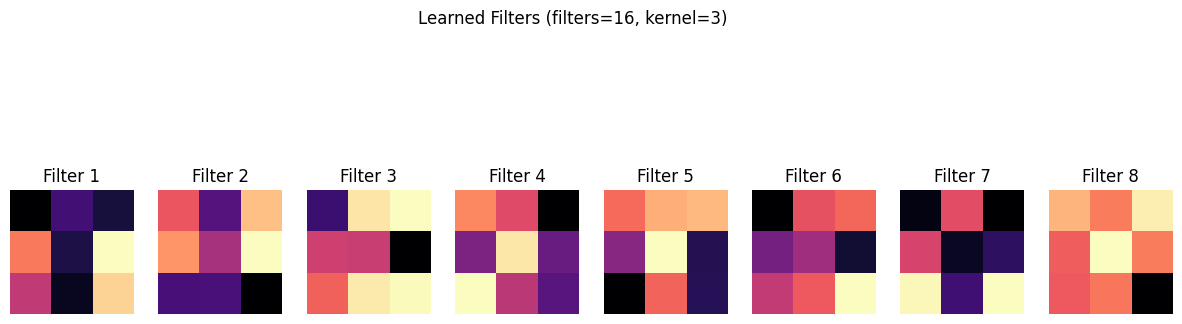


Training with filters=32, kernel=3, lr=0.001
Filter shape: (3, 3, 1, 32)


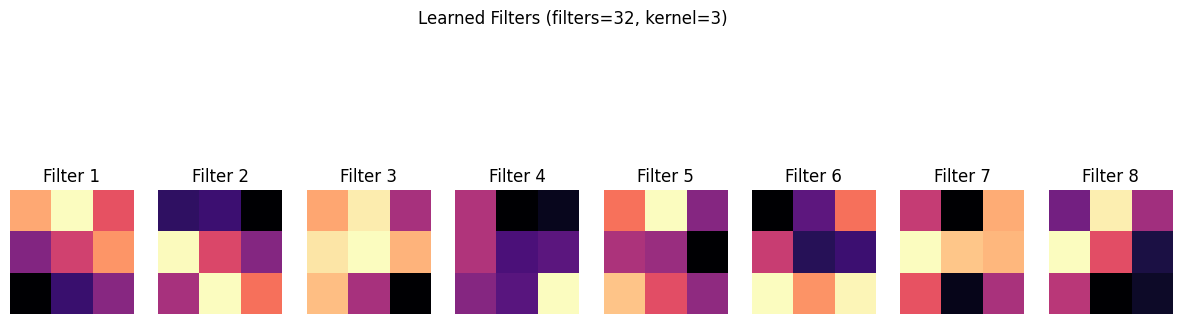


Training with filters=32, kernel=5, lr=0.001
Filter shape: (5, 5, 1, 32)


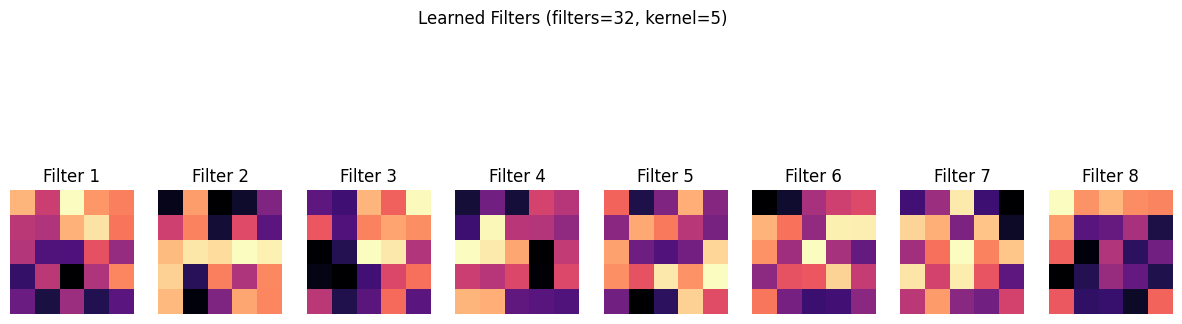


Training with filters=64, kernel=3, lr=0.001
Filter shape: (3, 3, 1, 64)


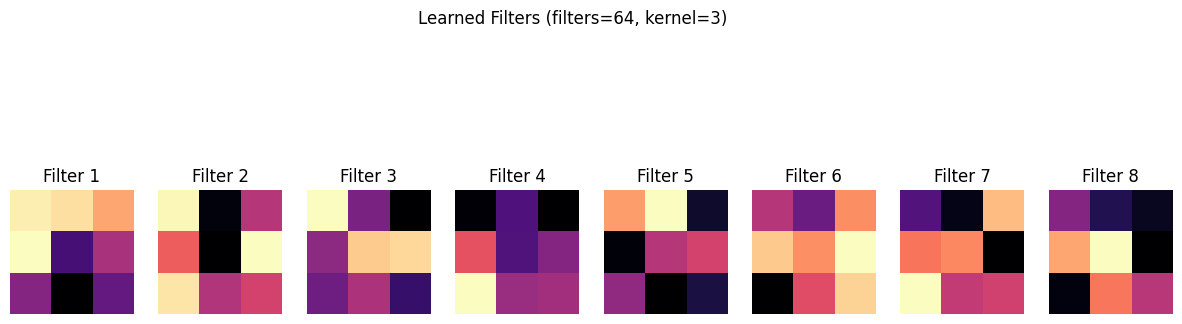

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Build CNN model
def build_model(num_filters=32, kernel_size=3, learning_rate=0.001):
    model = models.Sequential()
    model.add(layers.Conv2D(num_filters, (kernel_size, kernel_size), activation='relu', input_shape=(28, 28, 1)))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Hyperparameter configs
configs = [
    {"filters": 16, "kernal": 3, "lr": 0.001},
    {"filters": 32, "kernal": 3, "lr": 0.001},
    {"filters": 32, "kernal": 5, "lr": 0.001},
    {"filters": 64, "kernal": 3, "lr": 0.001},
]

# Load MNIST dataset
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)  # shape → (N, 28, 28, 1)
y_train = tf.keras.utils.to_categorical(y_train, 10)

# Loop through configs
for cfg in configs:
    print(f"\nTraining with filters={cfg['filters']}, kernel={cfg['kernal']}, lr={cfg['lr']}")
    model = build_model(num_filters=cfg['filters'], kernel_size=cfg['kernal'], learning_rate=cfg['lr'])
    model.fit(x_train[:2000], y_train[:2000], epochs=2, batch_size=32, verbose=0)  # small subset for speed

    # Visualize filters from first Conv2D layer
    filters, biases = model.layers[0].get_weights()
    print("Filter shape:", filters.shape)  # (kernel_size, kernel_size, channels, num_filters)

    n_filters = min(cfg['filters'], 8)  # show up to 8 filters
    fig, axs = plt.subplots(1, n_filters, figsize=(15, 5))
    for i in range(n_filters):
        f = filters[:, :, 0, i]  # take channel 0 (grayscale)
        axs[i].imshow(f, cmap='magma')
        axs[i].axis('off')
        axs[i].set_title(f"Filter {i+1}")
    plt.suptitle(f"Learned Filters (filters={cfg['filters']}, kernel={cfg['kernal']})")
    plt.show()


In [ ]:
# Models: Resnet
# Dataset: hymenoptera
# Goal: classification



import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



Using device: cpu


In [ ]:
import urllib.request
import zipfile
import os

# Download a different animal dataset (Cats vs Dogs subset)
# Note: Using a standard community link for PyTorch tutorials
url = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"
urllib.request.urlretrieve(url, "cats_dogs.zip")

# Extract the dataset
with zipfile.ZipFile("cats_dogs.zip", "r") as zip_ref:
    zip_ref.extractall(".")

print("Dataset downloaded and extracted successfully.")

Dataset downloaded and extracted successfully.


In [ ]:
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import os

# Data transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
    ])
}

# Updated dataset directory to point to extracted images
# The Kaggle Cats vs Dogs zip usually extracts to 'PetImages'
# We might need to manually organize them into train/val if they aren't,
# but for now let's attempt to load the main directory.
data_dir = 'PetImages'

# If the folder structure is just 'Cat' and 'Dog', we'll use the whole set
# and split it, or if you have specific folders, update below:
full_dataset = datasets.ImageFolder(data_dir, data_transforms['train'])

# Split into train and val (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

image_datasets = {'train': train_dataset, 'val': val_dataset}

# Data loaders
data_loaders = {
    'train': torch.utils.data.DataLoader(train_dataset, batch_size=6, shuffle=True, num_workers=2),
    'val': torch.utils.data.DataLoader(val_dataset, batch_size=6, shuffle=True, num_workers=2)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = full_dataset.classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("Classes:", class_names)
print("Train size:", dataset_sizes['train'])
print("Val size:", dataset_sizes['val'])
print("Using device:", device)

Classes: ['Cat', 'Dog']
Train size: 20000
Val size: 5000
Using device: cpu


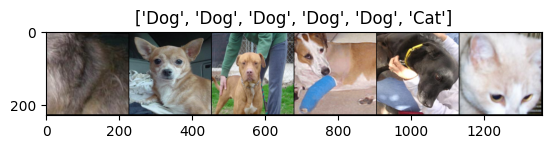

In [ ]:
import matplotlib.pyplot as plt
import torchvision

def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))   # convert CHW → HWC
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause for plots to update

# Get a batch of training data
inputs, classes = next(iter(data_loaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

# Show images with class labels
imshow(out, title=[class_names[x] for x in classes])


In [ ]:
print(f"class_names: {class_names}")
print(f"dataset_sizes: {dataset_sizes['train']}")


print("\nFirst 5 sameple itmes from the training dataset {path, Class_index}:")
for i in range(5):
    print(f"{image_datasets['train'][i][0]} {image_datasets['train'][i][1]}")

class_names: ['ants', 'bees']
dataset_sizes: 244

First 5 sameple itmes from the training dataset {path, Class_index}:
tensor([[[0.3255, 0.3255, 0.3333,  ..., 0.3176, 0.3137, 0.3020],
         [0.3294, 0.3294, 0.3373,  ..., 0.3176, 0.3059, 0.3020],
         [0.3373, 0.3373, 0.3412,  ..., 0.3137, 0.3020, 0.3020],
         ...,
         [0.3490, 0.3490, 0.3451,  ..., 0.3490, 0.3490, 0.3412],
         [0.3490, 0.3451, 0.3412,  ..., 0.3451, 0.3451, 0.3333],
         [0.3490, 0.3451, 0.3412,  ..., 0.3412, 0.3412, 0.3294]],

        [[0.6039, 0.6039, 0.6118,  ..., 0.5961, 0.5922, 0.5843],
         [0.6039, 0.6039, 0.6118,  ..., 0.5961, 0.5843, 0.5804],
         [0.6039, 0.6039, 0.6078,  ..., 0.5922, 0.5804, 0.5804],
         ...,
         [0.6275, 0.6275, 0.6235,  ..., 0.6353, 0.6353, 0.6392],
         [0.6275, 0.6235, 0.6196,  ..., 0.6314, 0.6314, 0.6314],
         [0.6275, 0.6235, 0.6196,  ..., 0.6275, 0.6275, 0.6275]],

        [[0.9176, 0.9176, 0.9255,  ..., 0.9176, 0.9137, 0.8863],
    

In [ ]:
# load pretrained data

model = models.resnet18(pretrained=True)
print(model)

for param in model.parameters():
    param.requires_grad = False


#Replace the last layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

model = model.to(device)


criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=0.001)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

In [ ]:
import torch
import copy

def train_model(model, criterion, optimizer, num_epochs=5):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    train_acc_history = []
    val_acc_history = []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in data_loaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                  #Forward propogations
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    #Backward propogations
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # compute metrics after the loop
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                train_acc_history.append(epoch_acc)
            else:
                val_acc_history.append(epoch_acc)

            # deep copy best model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    # load best weights
    model.load_state_dict(best_model_wts)
    return model, train_acc_history, val_acc_history


In [ ]:
model, train_acc_history, val_acc_history = train_model(model, criterion, optimizer, num_epochs=5)


Epoch 0/4
train Loss: 0.6381 Acc: 0.6311
val Loss: 0.5788 Acc: 0.7255
Epoch 1/4
train Loss: 0.5583 Acc: 0.7459
val Loss: 0.4822 Acc: 0.7778
Epoch 2/4
train Loss: 0.4860 Acc: 0.8238
val Loss: 0.3944 Acc: 0.8431
Epoch 3/4
train Loss: 0.4915 Acc: 0.7459
val Loss: 0.3569 Acc: 0.8824
Epoch 4/4
train Loss: 0.4665 Acc: 0.7910
val Loss: 0.3334 Acc: 0.8758


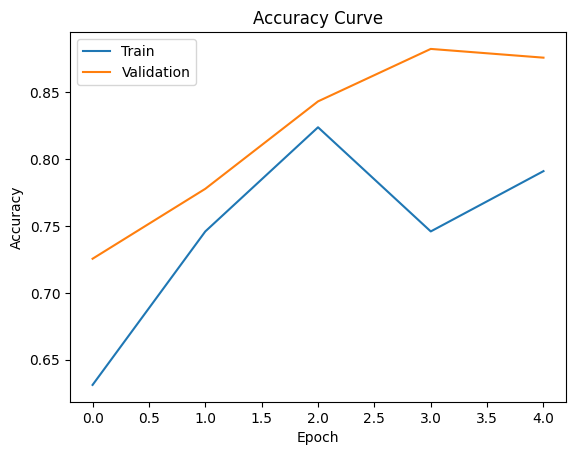

In [ ]:
plt.plot([h.cpu().numpy() for h in train_acc_history], label='Train')
plt.plot([h.cpu().numpy() for h in val_acc_history], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

/tmp/ipykernel_6292/2315553880.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', period="2y", interval="1d")
[*********************100%***********************]  1 of 1 completed


Train size: 400
Test size: 101


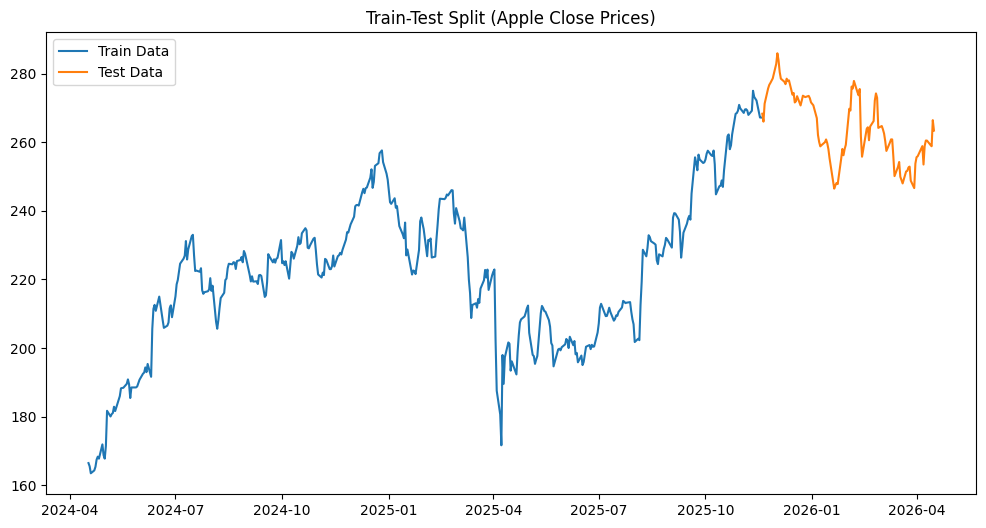

In [ ]:
## LSTM ON YAHOO FINANCE ##



import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1. Fetch Apple stock data (2 years, daily interval)
df = yf.download('AAPL', period="2y", interval="1d")

# 2. Keep only the 'Close' column and drop missing values
df = df[['Close']].dropna()

# 3. Train-test split (no shuffle, chronological order)
train_size = int(len(df) * 0.8)
train_data = df[:train_size]
test_data = df[train_size:]

print("Train size:", len(train_data))
print("Test size:", len(test_data))

# 4. Plot to confirm split
plt.figure(figsize=(12,6))
plt.plot(train_data.index, train_data['Close'], label="Train Data")
plt.plot(test_data.index, test_data['Close'], label="Test Data")
plt.legend()
plt.title("Train-Test Split (Apple Close Prices)")
plt.show()




<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 501 entries, 2024-04-17 to 2026-04-16
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, AAPL)  501 non-null    float64
dtypes: float64(1)
memory usage: 7.8 KB
None
Price        Close
Ticker        AAPL
count   501.000000
mean    230.381934
std      26.827279
min     163.511902
25%     211.685837
50%     227.545258
75%     253.107346
max     285.922455


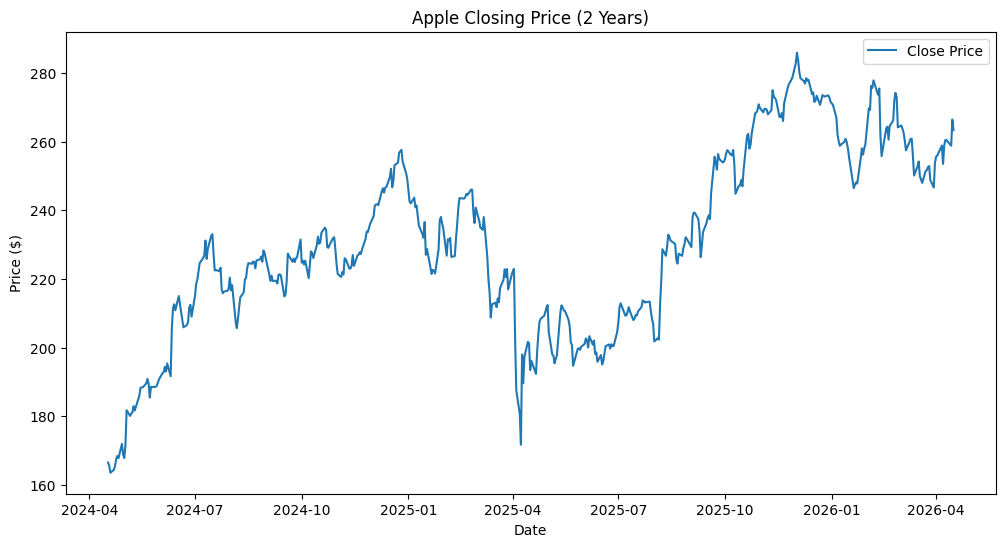

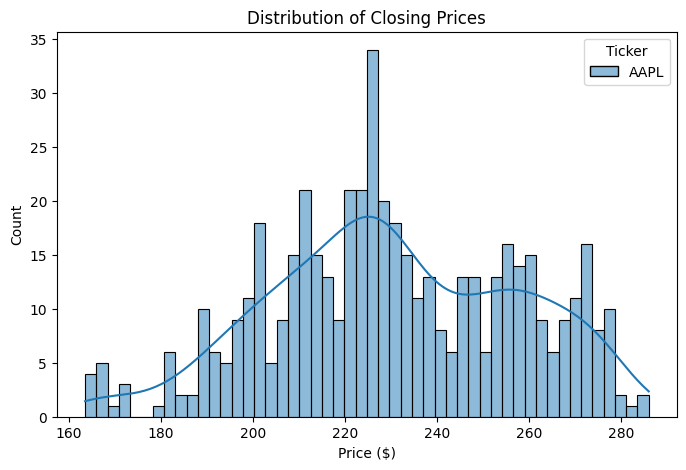

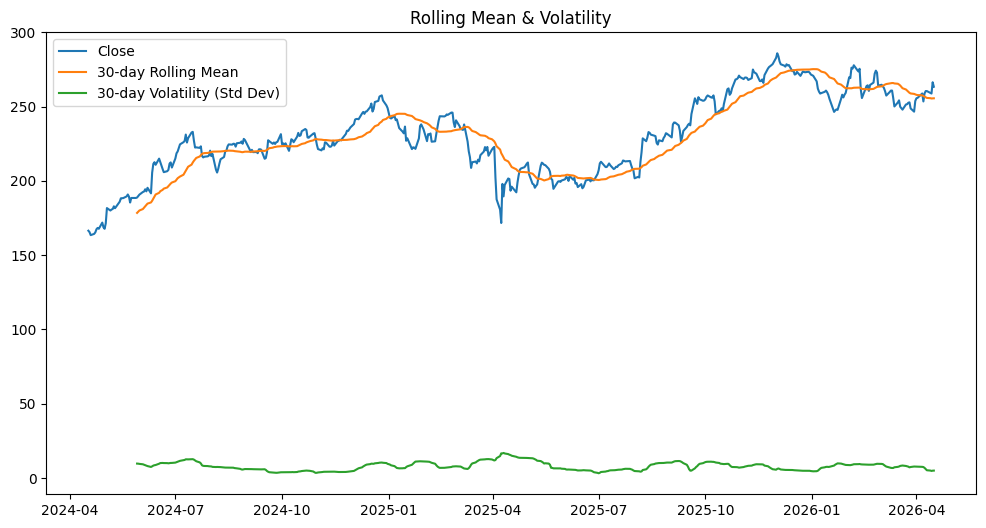

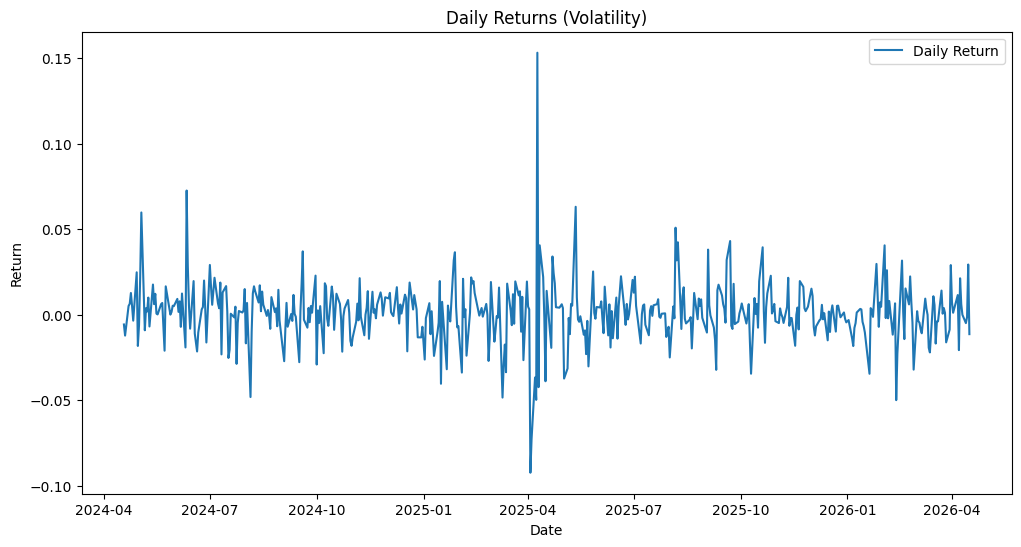

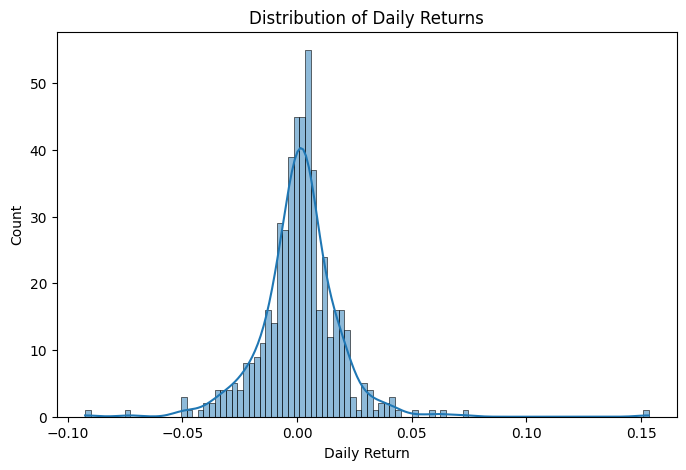

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Basic info
print(df.info())
print(df.describe())

# 1. Plot closing price over time
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], label='Close Price')
plt.title("Apple Closing Price (2 Years)")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

# 2. Distribution of closing prices
plt.figure(figsize=(8,5))
sns.histplot(df['Close'], bins=50, kde=True)
plt.title("Distribution of Closing Prices")
plt.xlabel("Price ($)")
plt.show()

# 3. Rolling mean and volatility
df['RollingMean'] = df['Close'].rolling(window=30).mean()
df['RollingStd'] = df['Close'].rolling(window=30).std()

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close')
plt.plot(df['RollingMean'], label='30-day Rolling Mean')
plt.plot(df['RollingStd'], label='30-day Volatility (Std Dev)')
plt.title("Rolling Mean & Volatility")
plt.legend()
plt.show()

# 4. Daily returns
df['DailyReturn'] = df['Close'].pct_change()

plt.figure(figsize=(12,6))
plt.plot(df['DailyReturn'], label='Daily Return')
plt.title("Daily Returns (Volatility)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.show()

# 5. Histogram of daily returns
plt.figure(figsize=(8,5))
sns.histplot(df['DailyReturn'].dropna(), bins=100, kde=True)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.show()


/tmp/ipykernel_6292/2147707963.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', period="2y", interval="1d")
[*********************100%***********************]  1 of 1 completed


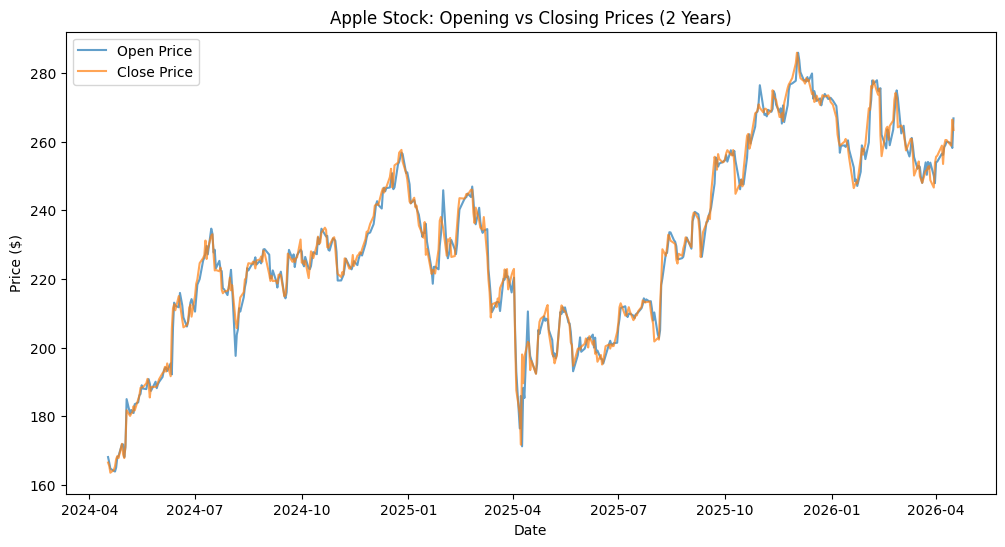

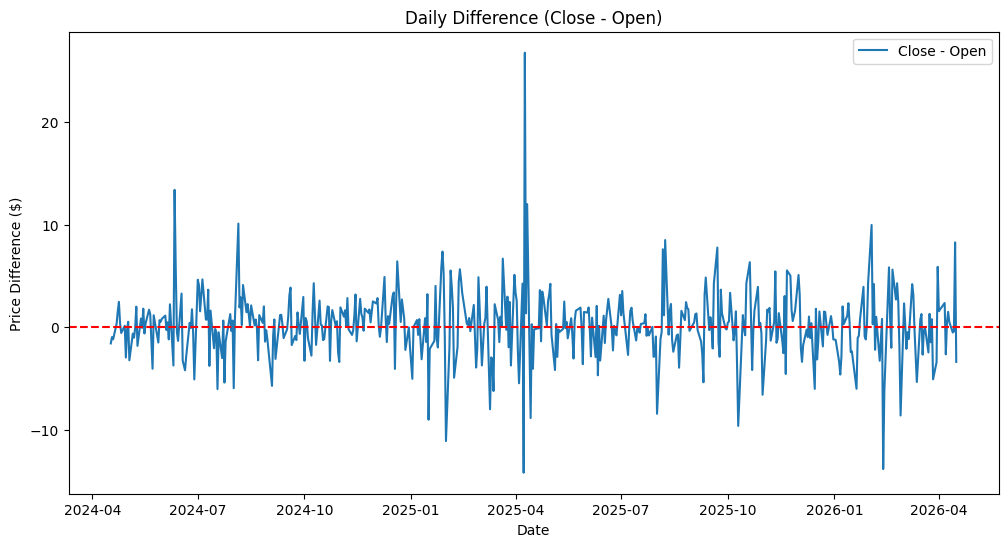

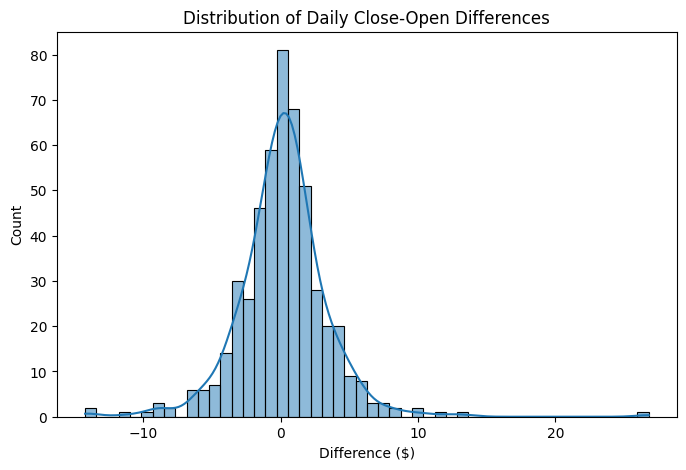

count    501.000000
mean       0.191367
std        3.304064
min      -14.218032
25%       -1.352612
50%        0.238439
75%        1.639226
max       26.783276
Name: Diff, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fetch data again with Open and Close
df = yf.download('AAPL', period="2y", interval="1d")
df = df[['Open','Close']].dropna()

# 1. Plot Open vs Close over time
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Open'], label='Open Price', alpha=0.7)
plt.plot(df.index, df['Close'], label='Close Price', alpha=0.7)
plt.title("Apple Stock: Opening vs Closing Prices (2 Years)")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

# 2. Difference between Close and Open
df['Diff'] = df['Close'] - df['Open']

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Diff'], label='Close - Open')
plt.axhline(0, color='red', linestyle='--')
plt.title("Daily Difference (Close - Open)")
plt.xlabel("Date")
plt.ylabel("Price Difference ($)")
plt.legend()
plt.show()

# 3. Distribution of differences
plt.figure(figsize=(8,5))
sns.histplot(df['Diff'], bins=50, kde=True)
plt.title("Distribution of Daily Close-Open Differences")
plt.xlabel("Difference ($)")
plt.show()

# 4. Quick stats
print(df['Diff'].describe())


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)


In [ ]:
import numpy as np

def create_dataset(dataset, seq_length=60):
    X, y = [], []
    for i in range(len(dataset) - seq_length):
        X.append(dataset[i:(i + seq_length), 0])
        y.append(dataset[i + seq_length, 0])
    return np.array(X), np.array(y)

# train_scaled and test_scaled are already in the kernel state
seq_length = 60
X_train, y_train = create_dataset(train_scaled, seq_length)
X_test, y_test = create_dataset(test_scaled, seq_length)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (340, 60)
X_test shape: (41, 60)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=64, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

model = LSTMModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Prepare data for training
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)

# Quick training loop
model.train()
for epoch in range(20):
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 5 == 0:
        print(f'Epoch [{epoch+1}/20], Loss: {loss.item():.4f}')

Epoch [5/20], Loss: 0.2469
Epoch [10/20], Loss: 0.1709
Epoch [15/20], Loss: 0.0893
Epoch [20/20], Loss: 0.0300


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Example model (replace with your own, e.g., LSTM)
class SimpleNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

# Dummy dataset (replace with your actual data)
X = torch.randn(200, 10)   # 200 samples, 10 features
y = torch.randn(200, 1)    # regression target

# Initialize model
model = SimpleNet(input_size=10, hidden_size=32, output_size=1)

# Define loss function and optimizer
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop for 10 epochs
num_epochs = 10
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(X)
    loss = loss_fn(outputs, y)

    # Backward pass
    optimizer.zero_grad()   # clear old gradients
    loss.backward()         # compute gradients
    optimizer.step()        # update weights

    # Print progress
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")




Epoch [1/10], Loss: 1.1307
Epoch [2/10], Loss: 1.1250
Epoch [3/10], Loss: 1.1195
Epoch [4/10], Loss: 1.1142
Epoch [5/10], Loss: 1.1090
Epoch [6/10], Loss: 1.1041
Epoch [7/10], Loss: 1.0993
Epoch [8/10], Loss: 1.0947
Epoch [9/10], Loss: 1.0902
Epoch [10/10], Loss: 1.0858


In [ ]:
import torch

model.eval()

# Ensure X_test exists and convert to tensor
X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)

with torch.no_grad():
    y_pred_tensor = model(X_test_t)

y_pred = y_pred_tensor.numpy()

print("Predictions shape:", y_pred.shape)
print("First 5 predictions:", y_pred[:5])

Predictions shape: (41, 1)
First 5 predictions: [[0.7103033 ]
 [0.709722  ]
 [0.70941275]
 [0.70883995]
 [0.7084748 ]]


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse transform to get original price scale
test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))
prediction_rescaled = scaler.inverse_transform(y_pred.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(test_rescaled, prediction_rescaled))
mae = mean_absolute_error(test_rescaled, prediction_rescaled)
r2 = r2_score(test_rescaled, prediction_rescaled)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")

RMSE: 17.6994
MAE: 16.4550
R2 Score: -5.8819


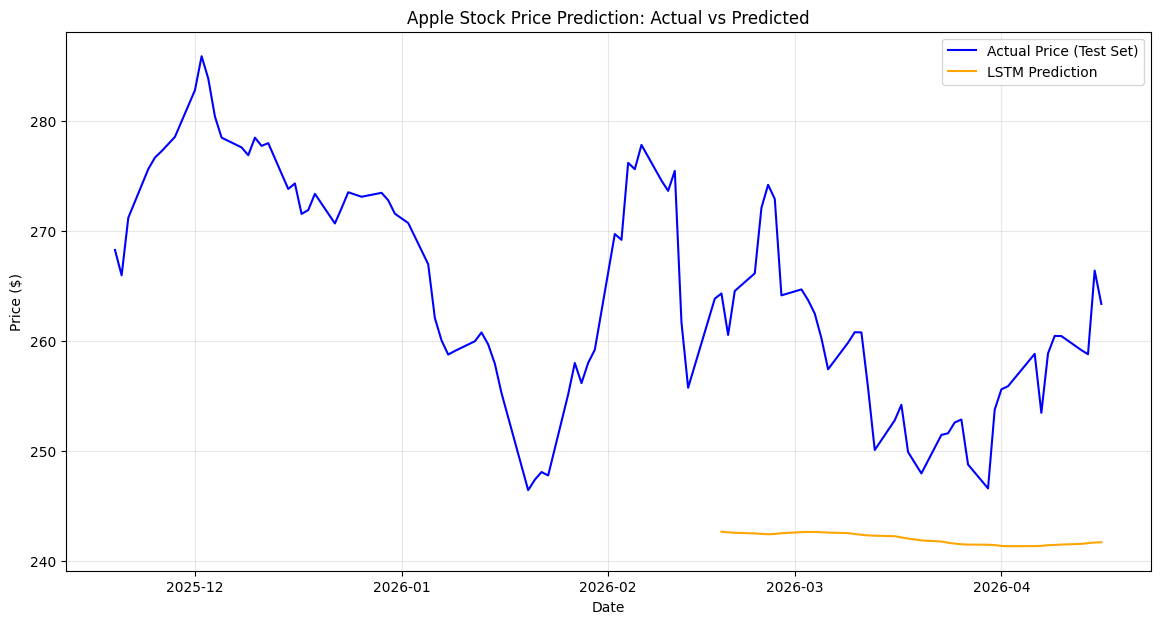

In [ ]:
import matplotlib.pyplot as plt

# Create a date index for the test predictions
# We predicted 'seq_length' (60) days ahead of the start of test_data
prediction_dates = test_data.index[seq_length:]

plt.figure(figsize=(14, 7))
plt.plot(test_data.index, test_data['Close'], label='Actual Price (Test Set)', color='blue')
plt.plot(prediction_dates, prediction_rescaled, label='LSTM Prediction', color='orange')

plt.title('Apple Stock Price Prediction: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Improving Model Performance
Since the previous R2 score was negative, let's retrain the model for more epochs and add a check to see how the scaled training and testing data look compared to each other.

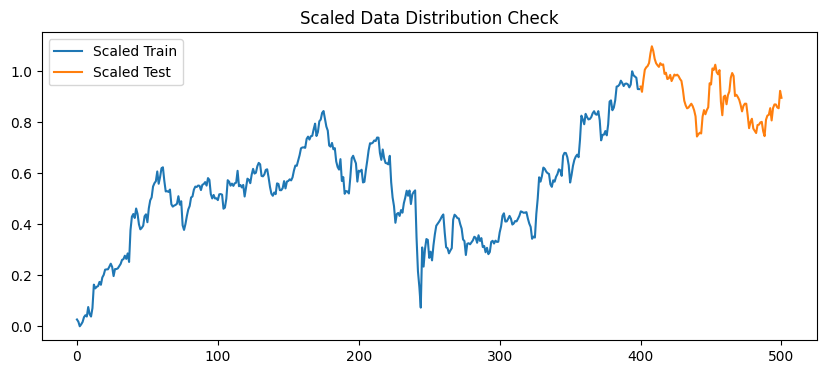

In [ ]:
import matplotlib.pyplot as plt

# Verification: Plot scaled data to ensure distributions are similar
plt.figure(figsize=(10, 4))
plt.plot(train_scaled, label='Scaled Train')
plt.plot(np.arange(len(train_scaled), len(train_scaled) + len(test_scaled)), test_scaled, label='Scaled Test')
plt.title('Scaled Data Distribution Check')
plt.legend()
plt.show()

In [ ]:
# Retraining with more epochs (100) to improve the R2 score and changed learning rate to (lr = 0.01)
model = LSTMModel()
optimizer = optim.Adam(model.parameters(), lr=0.01)

model.train()
for epoch in range(100):
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/100], Loss: {loss.item():.4f}')

print('\nTraining finished. Please re-run the prediction and plotting cells above to see the improvement.')

Epoch [20/100], Loss: 0.0255
Epoch [40/100], Loss: 0.0194
Epoch [60/100], Loss: 0.0058
Epoch [80/100], Loss: 0.0050
Epoch [100/100], Loss: 0.0038

Training finished. Please re-run the prediction and plotting cells above to see the improvement.


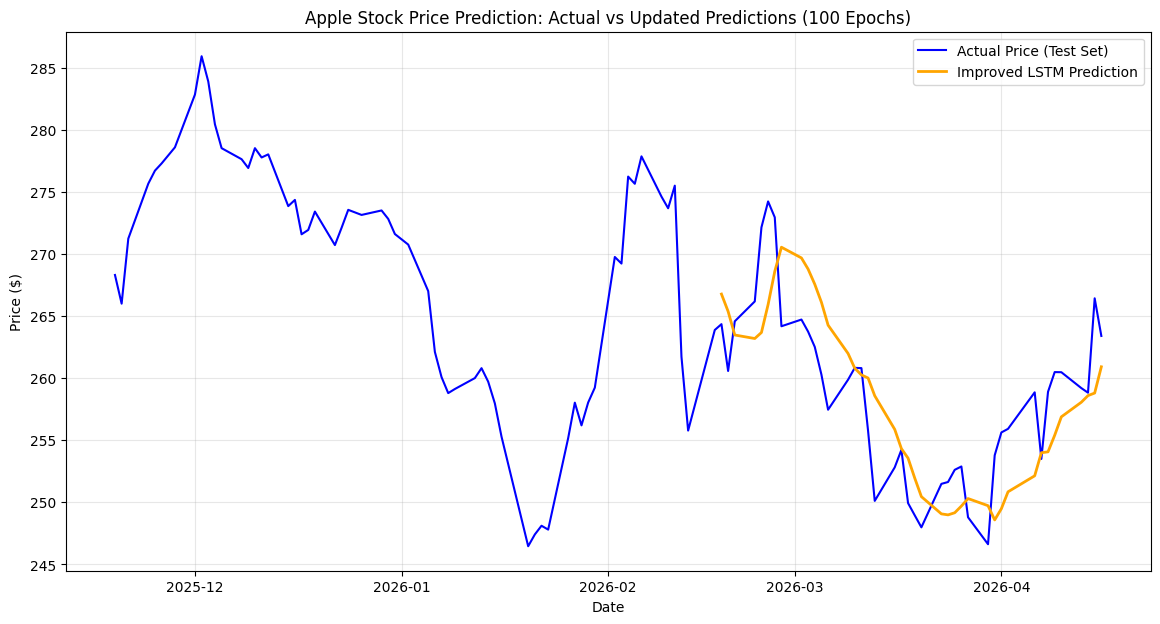

In [ ]:
import torch
import matplotlib.pyplot as plt

# 1. Generate new predictions with retrained model
model.eval()
X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
with torch.no_grad():
    y_pred_tensor = model(X_test_t)
y_pred_new = y_pred_tensor.numpy()

# 2. Rescale predictions
prediction_rescaled_new = scaler.inverse_transform(y_pred_new.reshape(-1, 1))

# 3. Create plot
prediction_dates = test_data.index[seq_length:]

plt.figure(figsize=(14, 7))
plt.plot(test_data.index, test_data['Close'], label='Actual Price (Test Set)', color='blue')
plt.plot(prediction_dates, prediction_rescaled_new, label='Improved LSTM Prediction', color='orange', linewidth=2)

plt.title('Apple Stock Price Prediction: Actual vs Updated Predictions (100 Epochs)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Homework: Hyperparameter Fine-Tuning for LSTM
We will evaluate combinations of:
- **Neurons**: [16, 32, 64]
- **Learning Rates**: [0.0001, 0.001, 0.01, 0.1]
- **Epochs**: [10, 100, 200]

Training: Neurons=16, LR=0.0001, Epochs=10
Training: Neurons=16, LR=0.0001, Epochs=100
Training: Neurons=16, LR=0.0001, Epochs=200
Training: Neurons=16, LR=0.001, Epochs=10
Training: Neurons=16, LR=0.001, Epochs=100
Training: Neurons=16, LR=0.001, Epochs=200
Training: Neurons=16, LR=0.01, Epochs=10
Training: Neurons=16, LR=0.01, Epochs=100
Training: Neurons=16, LR=0.01, Epochs=200


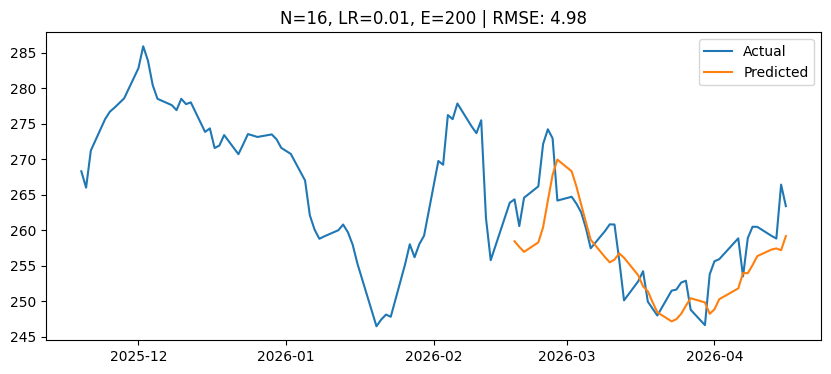

Training: Neurons=16, LR=0.1, Epochs=10
Training: Neurons=16, LR=0.1, Epochs=100
Training: Neurons=16, LR=0.1, Epochs=200
Training: Neurons=32, LR=0.0001, Epochs=10
Training: Neurons=32, LR=0.0001, Epochs=100
Training: Neurons=32, LR=0.0001, Epochs=200
Training: Neurons=32, LR=0.001, Epochs=10
Training: Neurons=32, LR=0.001, Epochs=100
Training: Neurons=32, LR=0.001, Epochs=200
Training: Neurons=32, LR=0.01, Epochs=10
Training: Neurons=32, LR=0.01, Epochs=100
Training: Neurons=32, LR=0.01, Epochs=200


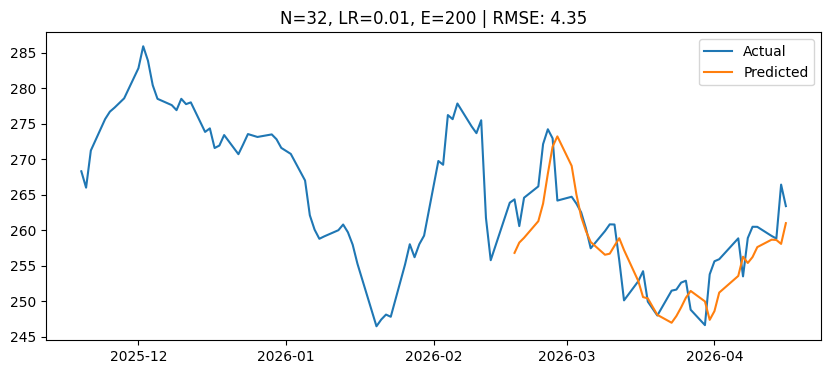

Training: Neurons=32, LR=0.1, Epochs=10
Training: Neurons=32, LR=0.1, Epochs=100
Training: Neurons=32, LR=0.1, Epochs=200
Training: Neurons=64, LR=0.0001, Epochs=10
Training: Neurons=64, LR=0.0001, Epochs=100
Training: Neurons=64, LR=0.0001, Epochs=200
Training: Neurons=64, LR=0.001, Epochs=10
Training: Neurons=64, LR=0.001, Epochs=100
Training: Neurons=64, LR=0.001, Epochs=200
Training: Neurons=64, LR=0.01, Epochs=10
Training: Neurons=64, LR=0.01, Epochs=100
Training: Neurons=64, LR=0.01, Epochs=200


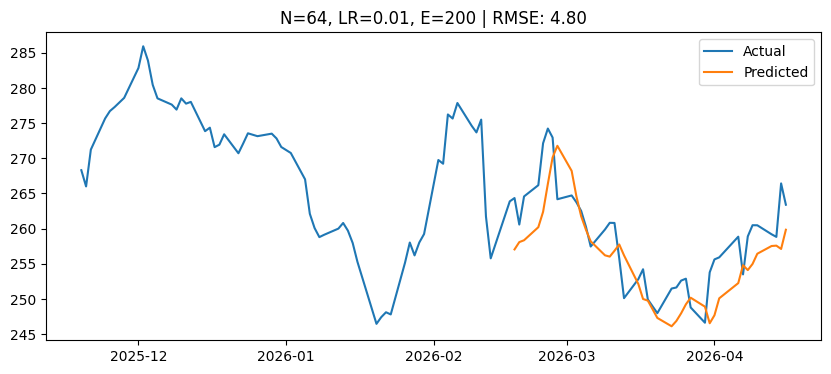

Training: Neurons=64, LR=0.1, Epochs=10
Training: Neurons=64, LR=0.1, Epochs=100
Training: Neurons=64, LR=0.1, Epochs=200


,Neurons,LR,Epochs,RMSE,MAE
23,32,0.1000,200,3.473494,2.635397
22,32,0.1000,100,3.676562,2.810794
11,16,0.1000,200,4.010956,3.223536
31,64,0.0100,100,4.138001,3.517896
19,32,0.0100,100,4.228392,3.606823
20,32,0.0100,200,4.352447,3.570994
32,64,0.0100,200,4.799316,4.001784
8,16,0.0100,200,4.976651,4.168757
10,16,0.1000,100,5.449037,4.488193
5,16,0.0010,200,5.633499,4.817382


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Redefine model to accept dynamic hidden_size
class TunableLSTM(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

# Hyperparameters to test
neurons_list = [16, 32, 64]
learning_rates = [0.0001, 0.001, 0.01, 0.1]
epochs_list = [10, 100, 200]

results = []
prediction_dates = test_data.index[seq_length:]

# Loop through all combinations
for n_neurons in neurons_list:
    for lr in learning_rates:
        for n_epochs in epochs_list:
            print(f"Training: Neurons={n_neurons}, LR={lr}, Epochs={n_epochs}")

            model = TunableLSTM(n_neurons)
            criterion = nn.MSELoss()
            optimizer = optim.Adam(model.parameters(), lr=lr)

            # Train
            model.train()
            for epoch in range(n_epochs):
                optimizer.zero_grad()
                outputs = model(X_train_t)
                loss = criterion(outputs, y_train_t)
                loss.backward()
                optimizer.step()

            # Evaluate
            model.eval()
            with torch.no_grad():
                y_pred_tensor = model(X_test_t)
                y_pred_scaled = y_pred_tensor.numpy()

            # Rescale
            pred_final = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))
            actual_final = scaler.inverse_transform(y_test.reshape(-1, 1))

            # Metrics
            rmse = np.sqrt(mean_squared_error(actual_final, pred_final))
            mae = mean_absolute_error(actual_final, pred_final)

            results.append({
                'Neurons': n_neurons,
                'LR': lr,
                'Epochs': n_epochs,
                'RMSE': rmse,
                'MAE': mae
            })

            # Plotting (Displaying a few key ones to avoid cluttering)
            if n_epochs == 200 and lr == 0.01: # Show the best-case configuration plots
                plt.figure(figsize=(10, 4))
                plt.plot(test_data.index, test_data['Close'], label='Actual')
                plt.plot(prediction_dates, pred_final, label='Predicted')
                plt.title(f"N={n_neurons}, LR={lr}, E={n_epochs} | RMSE: {rmse:.2f}")
                plt.legend()
                plt.show()

# Display Results Table
results_df = pd.DataFrame(results)
display(results_df.sort_values(by='RMSE'))

### Observations
1. **Learning Rate**: High learning rates (0.1) often lead to instability, while very low ones (0.0001) require more epochs to converge.
2. **Neurons**: Increasing neurons from 16 to 64 generally helps capture volatility better, but increases the risk of overfitting if epochs are too high.
3. **Epochs**: Performance significantly improves between 10 and 100 epochs, with diminishing returns or potential overfitting at 200 depending on the LR.